In [12]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
# plot_utils.linclab_plt_defaults(font="Arial", fontdir="fonts")
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

api = wandb.Api(timeout=19)

In [13]:
import pandas as pd
from matplotlib.ticker import ScalarFormatter

In [14]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters)
    #print(f"Runs for project '{project_name}':")
    return runs

In [15]:
def same_config(config1, config2, keys=['normtype']):
    for key in keys:
        if config1[key] != config2[key]:
            return False
    return True

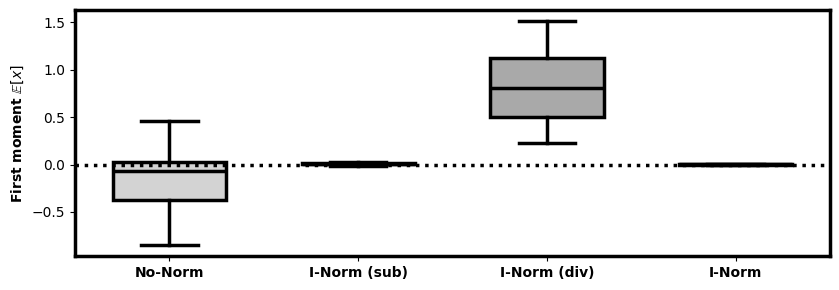

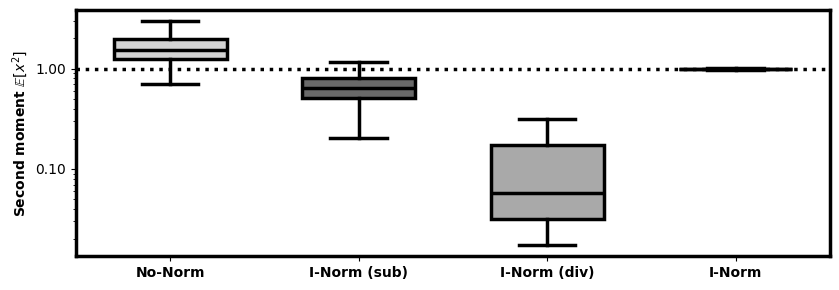

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mu_var_boxplot_comparison(epsilons):
    ln_feedback_types = ['No-Norm', 'I-Norm (sub)', 'I-Norm (div)', 'I-Norm']
    # strictly black and white/grayscale palette
    colors = {
        'No-Norm': 'lightgray',
        'I-Norm (sub)': 'dimgray',
        'I-Norm (div)': 'darkgray',
        'I-Norm': 'white',
    }
    edge_color = 'black'
    lw = 2.5  # Base line thickness

    mu_data = {t: [] for t in ln_feedback_types}
    var_data = {t: [] for t in ln_feedback_types}

    for epsilon in epsilons:
        for ln_fdb in ln_feedback_types:
            project = 'Luminosity_LNHomeostasis'
            if ln_fdb == 'I-Norm (sub)':
                filters = {
                    "config.dataset": "fashionmnist",
                    "config.brightness_factor": epsilon,
                    "config.homeostasis": 1,
                    "config.shunting": 0,
                    "config.subtractive": 1,
                    "config.normtype_detach": 1,
                    "config.use_testset": True,
                    "config.is_dann": 1,
                    "config.normtype": 0,
                }
            elif ln_fdb == 'I-Norm (div)':
                filters = {
                    "config.dataset": "fashionmnist",
                    "config.brightness_factor": epsilon,
                    "config.homeostasis": 1,
                    "config.shunting": 1,
                    "config.subtractive": 0,
                    "config.normtype_detach": 1,
                    "config.use_testset": True,
                    "config.is_dann": 1,
                    "config.normtype": 0,
                }
            else:
                filters = {
                    "config.dataset": "fashionmnist",
                    "config.brightness_factor": epsilon,
                    "config.homeostasis": 1 if ln_fdb == 'I-Norm' else 0,
                    "config.normtype": 0,
                    "config.normtype_detach": 1,
                    "config.subtractive": None,
                    "config.excitation_training": 1 if ln_fdb == 'I-Norm' else 0,
                    "config.layer_norm": 0,
                    "config.use_testset": True,
                }

            runs = fetch_runs(
                api,
                entity='royeyono',
                project_name=project,
                filters=filters,
                order="-summary_metrics.test_acc"
            )[:10]

            for run in runs:
                try:
                    mu0 = float(run.summary.get("train_fc0_mu", np.nan))
                    mu1 = float(run.summary.get("train_fc1_mu", np.nan))
                    var0 = float(run.summary.get("train_fc0_var", np.nan))
                    var1 = float(run.summary.get("train_fc1_var", np.nan))
                except (TypeError, ValueError):
                    continue

                if not np.any(np.isnan([mu0, mu1, var0, var1])):
                    mu_data[ln_fdb].append((mu0 + mu1) / 2)
                    var_data[ln_fdb].append((var0 + var1) / 2)

    def create_boxplot(data_dict, ylabel, filename, y_hline=None, use_log=False):
        fig, ax = plt.subplots(figsize=(8.5, 3))
        plot_list = [data_dict[t] for t in ln_feedback_types]

        # Modified for thickness and BW style
        bp = ax.boxplot(
            plot_list,
            patch_artist=True,
            widths=0.6,
            showfliers=False,  # REMOVE OUTLIERS
            boxprops=dict(linewidth=lw, color=edge_color),
            whiskerprops=dict(linewidth=lw, color=edge_color),
            capprops=dict(linewidth=lw, color=edge_color),
            medianprops=dict(linewidth=lw, color=edge_color), # BLACK MEDIAN
        )

        for patch, t in zip(bp['boxes'], ln_feedback_types):
            patch.set_facecolor(colors[t])

        if y_hline is not None:
            ax.axhline(y_hline, color='black', linestyle='dotted', linewidth=lw)

        ax.set_xticklabels(ln_feedback_types, fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')

        # Make axes spines thicker
        for spine in ax.spines.values():
            spine.set_linewidth(lw)

        if use_log:
            ax.set_yscale("log")
            ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

        plt.tight_layout()
        # plt.savefig(filename, format="svg")
        plt.show()

    # Generate plots
    create_boxplot(mu_data, r"First moment $\mathbb{E}[x]$", "fig_mu_bw.svg", y_hline=0)
    create_boxplot(var_data, r"Second moment $\mathbb{E}[x^2]$", "fig_var_bw.svg", y_hline=1, use_log=True)

# Usage
epsilons = [0.0, 0.25, 0.5, 0.75]
plot_mu_var_boxplot_comparison(epsilons)


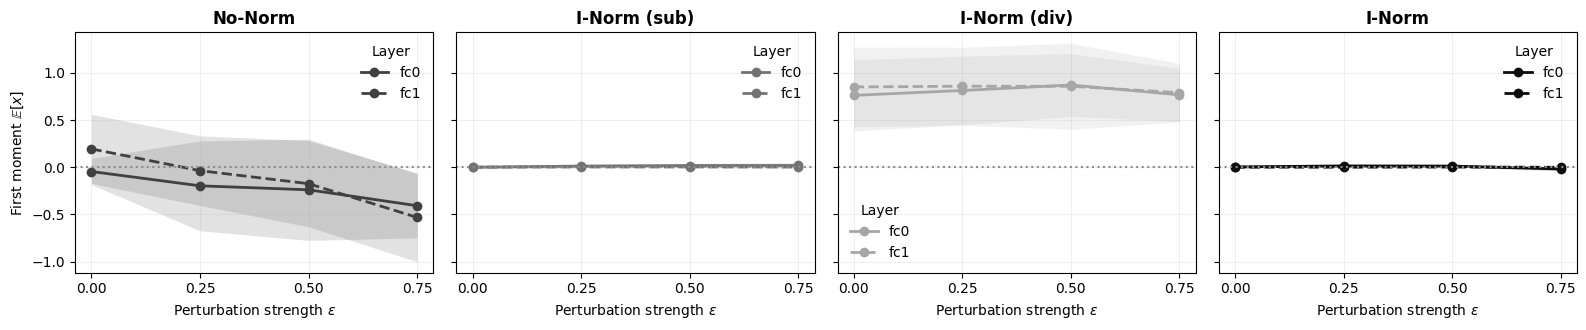

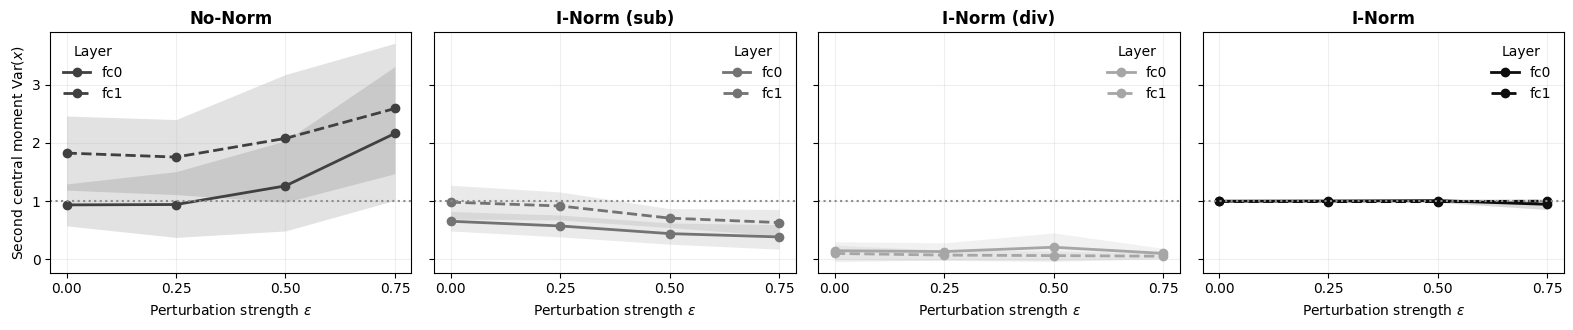

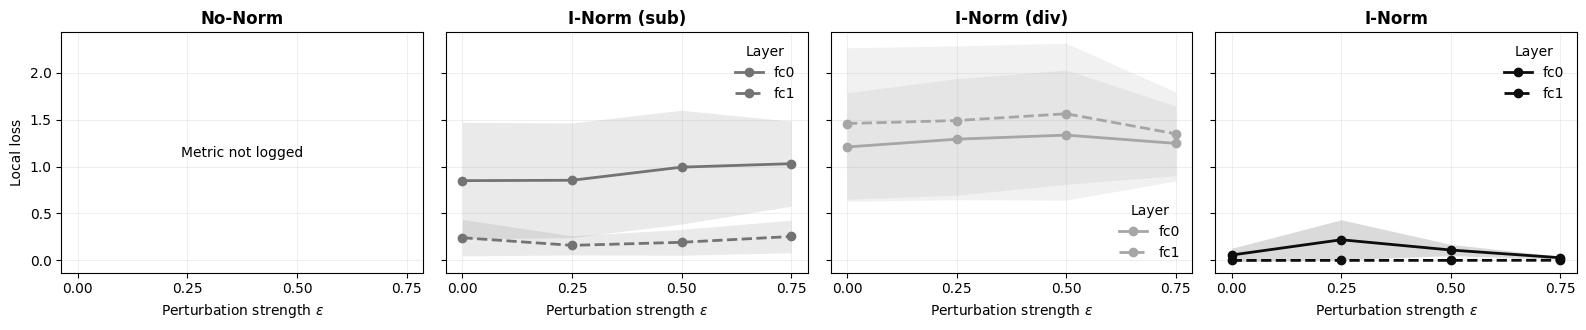

(<Figure size 1600x340 with 4 Axes>,
 array([<Axes: title={'center': 'No-Norm'}, xlabel='Perturbation strength $\\epsilon$', ylabel='Local loss'>,
        <Axes: title={'center': 'I-Norm (sub)'}, xlabel='Perturbation strength $\\epsilon$'>,
        <Axes: title={'center': 'I-Norm (div)'}, xlabel='Perturbation strength $\\epsilon$'>,
        <Axes: title={'center': 'I-Norm'}, xlabel='Perturbation strength $\\epsilon$'>],
       dtype=object))

In [17]:
# Per-layer line plots across perturbation strength.
# Each figure contains one panel per normalization category and one line per layer.
from collections import defaultdict

CATEGORIES = ('No-Norm', 'I-Norm (sub)', 'I-Norm (div)', 'I-Norm')
CATEGORY_COLORS = {
    'No-Norm': '0.25',
    'I-Norm (sub)': '0.45',
    'I-Norm (div)': '0.65',
    'I-Norm': '0.05',
}
METRICS = {
    'mu': (r'First moment $\mathbb{E}[x]$', 0.0),
    'var': (r'Second central moment $\mathrm{Var}(x)$', 1.0),
    'local_loss': ('Local loss', None),
}


def _category_query(category, epsilon):
    """Return the project and filters used by the existing Fig. 3 analysis."""
    if category == 'I-Norm (sub)':
        return 'Luminosity_LNHomeostasis', {
            'config.dataset': 'fashionmnist',
            'config.brightness_factor': epsilon,
            'config.homeostasis': 1,
            'config.shunting': 0,
            'config.subtractive': 1,
            'config.normtype_detach': 1,
            'config.use_testset': True,
            'config.is_dann': 1,
            'config.normtype': 0,
        }

    if category == 'I-Norm (div)':
        return 'Luminosity_LNHomeostasis', {
            'config.dataset': 'fashionmnist',
            'config.brightness_factor': epsilon,
            'config.homeostasis': 1,
            'config.shunting': 1,
            'config.subtractive': 0,
            'config.normtype_detach': 1,
            'config.use_testset': True,
            'config.is_dann': 1,
            'config.normtype': 0,
        }

    return 'Luminosity_LNHomeostasis', {
        'config.dataset': 'fashionmnist',
        'config.brightness_factor': epsilon,
        'config.homeostasis': int(category == 'I-Norm'),
        'config.normtype': 0,
        'config.normtype_detach': 1,
        'config.subtractive': None,
        'config.excitation_training': int(category == 'I-Norm'),
        'config.layer_norm': 0,
        'config.use_testset': True,
    }


def collect_layer_metrics(epsilons, top_k=10):
    """Collect final logged metrics as metric/category/layer/epsilon/value."""
    values = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    metric_pattern = re.compile(r'^train_(fc\d+)_(mu|var|local_loss)$')

    for epsilon in epsilons:
        for category in CATEGORIES:
            project, filters = _category_query(category, epsilon)
            runs = fetch_runs(
                api,
                entity='royeyono',
                project_name=project,
                filters=filters,
                order='-summary_metrics.test_acc',
            )[:top_k]

            for run in runs:
                for key in run.summary.keys():
                    match = metric_pattern.match(key)
                    if match is None:
                        continue
                    layer, metric = match.groups()
                    try:
                        value = float(run.summary[key])
                    except (TypeError, ValueError):
                        continue
                    if np.isfinite(value):
                        values[metric][category][layer][epsilon].append(value)

    return values


def plot_layer_metric_lines(values, epsilons, metric, *, savepath=None):
    """Plot one metric with category panels and per-layer mean ± SD lines."""
    ylabel, target = METRICS[metric]
    layers = sorted({
        layer
        for category_values in values[metric].values()
        for layer in category_values
    })
    line_styles = ['-', '--', ':', '-.']

    fig, axes = plt.subplots(
        1, len(CATEGORIES), figsize=(16, 3.4), sharex=True, sharey=True
    )

    for ax, category in zip(axes, CATEGORIES):
        plotted = False
        for layer_index, layer in enumerate(layers):
            means, stds = [], []
            for epsilon in epsilons:
                samples = np.asarray(
                    values[metric][category][layer].get(epsilon, []), dtype=float
                )
                means.append(samples.mean() if samples.size else np.nan)
                stds.append(samples.std(ddof=1) if samples.size > 1 else 0.0)

            means = np.asarray(means)
            stds = np.asarray(stds)
            valid = np.isfinite(means)
            if not valid.any():
                continue

            plotted = True
            color = CATEGORY_COLORS[category]
            ax.plot(
                np.asarray(epsilons)[valid],
                means[valid],
                marker='o',
                linestyle=line_styles[layer_index % len(line_styles)],
                linewidth=2,
                color=color,
                label=layer,
            )
            ax.fill_between(
                np.asarray(epsilons)[valid],
                (means - stds)[valid],
                (means + stds)[valid],
                color=color,
                alpha=0.15,
                linewidth=0,
            )

        if target is not None:
            ax.axhline(target, color='0.55', linestyle=':', linewidth=1.5)
        if not plotted:
            ax.text(0.5, 0.5, 'Metric not logged', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(category, fontweight='bold')
        ax.set_xlabel(r'Perturbation strength $\epsilon$')
        ax.set_xticks(epsilons)
        ax.grid(alpha=0.2)
        if plotted:
            ax.legend(title='Layer', frameon=False)

    axes[0].set_ylabel(ylabel)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches='tight')
    plt.show()
    return fig, axes


# Fetch once, then create separate figures for all three requested quantities.
epsilons = [0.0, 0.25, 0.5, 0.75]
layer_metric_values = collect_layer_metrics(epsilons, top_k=10)

plot_layer_metric_lines(layer_metric_values, epsilons, 'mu')
plot_layer_metric_lines(layer_metric_values, epsilons, 'var')
plot_layer_metric_lines(layer_metric_values, epsilons, 'local_loss')


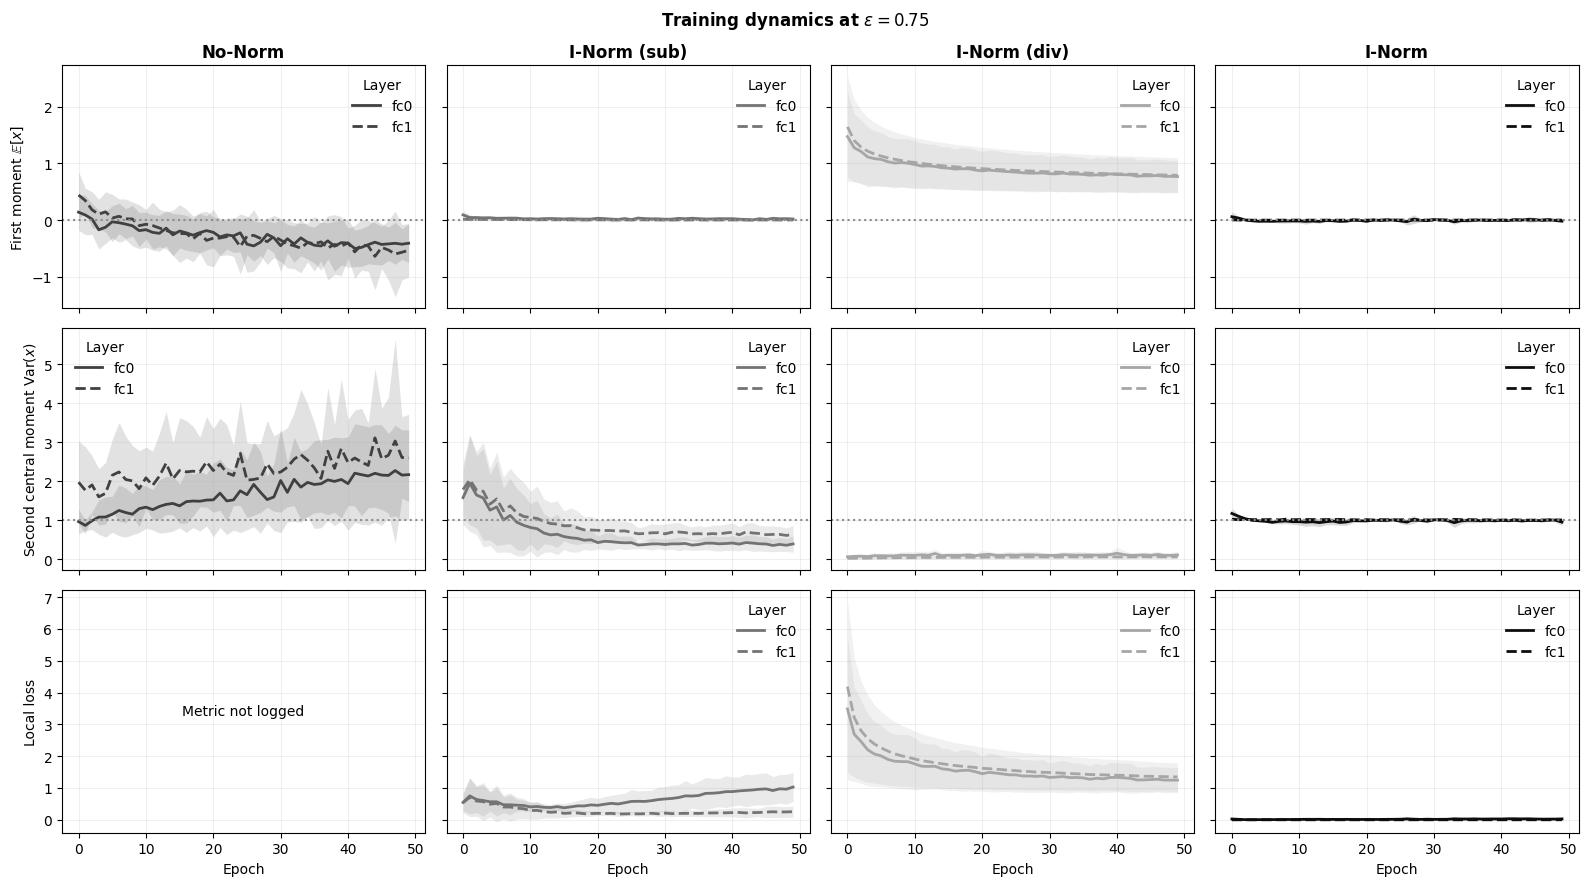

(<Figure size 1600x900 with 12 Axes>,
 array([[<Axes: title={'center': 'No-Norm'}, ylabel='First moment $\\mathbb{E}[x]$'>,
         <Axes: title={'center': 'I-Norm (sub)'}>,
         <Axes: title={'center': 'I-Norm (div)'}>,
         <Axes: title={'center': 'I-Norm'}>],
        [<Axes: ylabel='Second central moment $\\mathrm{Var}(x)$'>,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='Epoch', ylabel='Local loss'>,
         <Axes: xlabel='Epoch'>, <Axes: xlabel='Epoch'>,
         <Axes: xlabel='Epoch'>]], dtype=object))

In [18]:
# Epoch-wise version: rows are metrics, columns are normalization categories,
# and each line represents one layer. Select the perturbation strength below.
def collect_epoch_layer_metrics(epsilon, top_k=10):
    """Collect complete W&B histories, grouped by metric/category/layer/epoch."""
    values = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    metric_pattern = re.compile(r'^train_(fc\d+)_(mu|var|local_loss)$')

    for category in CATEGORIES:
        project, filters = _category_query(category, epsilon)
        runs = fetch_runs(
            api,
            entity='royeyono',
            project_name=project,
            filters=filters,
            order='-summary_metrics.test_acc',
        )[:top_k]

        for run in runs:
            # No key filter is used here because scan_history otherwise keeps only
            # rows containing every requested key; some categories lack local loss.
            for row in run.scan_history(page_size=1000):
                epoch = row.get('epoch_i')
                if epoch is None:
                    continue
                try:
                    epoch = int(epoch)
                except (TypeError, ValueError):
                    continue

                for key, raw_value in row.items():
                    match = metric_pattern.match(key)
                    if match is None:
                        continue
                    layer, metric = match.groups()
                    try:
                        value = float(raw_value)
                    except (TypeError, ValueError):
                        continue
                    if np.isfinite(value):
                        values[metric][category][layer][epoch].append(value)

    return values


def plot_epoch_layer_metrics(values, epsilon, *, savepath=None):
    """Create one metrics × category figure from complete training histories."""
    layers = sorted({
        layer
        for metric in METRICS
        for category_values in values[metric].values()
        for layer in category_values
    })
    line_styles = ['-', '--', ':', '-.']
    fig, axes = plt.subplots(
        len(METRICS),
        len(CATEGORIES),
        figsize=(16, 9),
        sharex='col',
        sharey='row',
        squeeze=False,
    )

    for row_index, (metric, (ylabel, target)) in enumerate(METRICS.items()):
        for column_index, category in enumerate(CATEGORIES):
            ax = axes[row_index, column_index]
            plotted = False

            for layer_index, layer in enumerate(layers):
                epoch_values = values[metric][category][layer]
                epochs = np.asarray(sorted(epoch_values))
                if not epochs.size:
                    continue

                means = np.asarray([
                    np.mean(epoch_values[epoch]) for epoch in epochs
                ])
                stds = np.asarray([
                    np.std(epoch_values[epoch], ddof=1)
                    if len(epoch_values[epoch]) > 1 else 0.0
                    for epoch in epochs
                ])

                plotted = True
                color = CATEGORY_COLORS[category]
                ax.plot(
                    epochs,
                    means,
                    color=color,
                    linestyle=line_styles[layer_index % len(line_styles)],
                    linewidth=2,
                    label=layer,
                )
                ax.fill_between(
                    epochs,
                    means - stds,
                    means + stds,
                    color=color,
                    alpha=0.15,
                    linewidth=0,
                )

            if target is not None:
                ax.axhline(target, color='0.55', linestyle=':', linewidth=1.5)
            if not plotted:
                ax.text(
                    0.5,
                    0.5,
                    'Metric not logged',
                    ha='center',
                    va='center',
                    transform=ax.transAxes,
                )
            if row_index == 0:
                ax.set_title(category, fontweight='bold')
            if row_index == len(METRICS) - 1:
                ax.set_xlabel('Epoch')
            if column_index == 0:
                ax.set_ylabel(ylabel)
            ax.grid(alpha=0.2)
            if plotted:
                ax.legend(title='Layer', frameon=False)

    fig.suptitle(rf'Training dynamics at $\epsilon={epsilon:g}$', fontweight='bold')
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches='tight')
    plt.show()
    return fig, axes


# Change this value to 0.25, 0.5, or 0.75 for another perturbation strength.
epoch_epsilon = 0.75
epoch_layer_metric_values = collect_epoch_layer_metrics(epoch_epsilon, top_k=10)
plot_epoch_layer_metrics(epoch_layer_metric_values, epoch_epsilon)
